<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/Tutorial_9_RNN_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Tutorial 9
# Sequential Modeling for Text Classification Using RNN
**Student ID:** 2408252



## Step 0: Install & Import Libraries

In [ ]:
!pip install wordcloud -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("TF version:", tf.__version__)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


TF version: 2.20.0


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## Task 1: Data Preprocessing & Cleaning

In [ ]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Sentiment140 columns: polarity, id, date, query, user, text
col_names = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=col_names
)

# Keep only text and sentiment; map 4 → 1 (positive), 0 stays 0 (negative)
df = df[['text', 'sentiment']].copy()
df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

# Use a balanced sample of 100k for faster training
pos = df[df['sentiment'] == 1].sample(50000, random_state=42)
neg = df[df['sentiment'] == 0].sample(50000, random_state=42)
data = pd.concat([pos, neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", data.shape)
print(data['sentiment'].value_counts())
data.head()

Dataset shape: (100000, 2)
sentiment
0    50000
1    50000
Name: count, dtype: int64


,text,sentiment
0,says sad to say pero makakabukas lng me ng pc ...,0
1,Allergies suck ducks nuts. &lt;=====8@8===...,0
2,@jordanknight U 5 guys could be standing in th...,1
3,Just went through some of my niece's clothes f...,0
4,"maybe i should take up drinking again, feel as...",0


In [ ]:
# ── Text Cleaning Function ────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Basic contraction map
contractions = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "i'm": "i am", "it's": "it is", "i've": "i have",
    "you're": "you are", "they're": "they are", "we're": "we are",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "didn't": "did not", "doesn't": "does not", "wouldn't": "would not"
}

def expand_contractions(text):
    for k, v in contractions.items():
        text = text.replace(k, v)
    return text

def preprocess_text(text):
    text = str(text).lower()                                          # Lowercase
    text = expand_contractions(text)                                  # Contractions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)              # Remove URLs
    text = re.sub(r'\@\w+|\#', '', text)                              # Remove mentions/hashtags
    text = re.sub(r'[^\w\s]', '', text)                               # Remove punctuation
    text = re.sub(r'\d+', '', text)                                   # Remove numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

print("Cleaning text... (this takes ~1-2 min)")
data['cleaned_text'] = data['text'].apply(preprocess_text)
print("Done!")
data[['text', 'sentiment', 'cleaned_text']].head()

Cleaning text... (this takes ~1-2 min)
Done!


,text,sentiment,cleaned_text
0,says sad to say pero makakabukas lng me ng pc ...,0,say sad say pero makakabukas lng ng pc tuwing ...
1,Allergies suck ducks nuts. &lt;=====8@8===...,0,allergy suck duck nut ltgt
2,@jordanknight U 5 guys could be standing in th...,1,u guy could standing north pole would still ho...
3,Just went through some of my niece's clothes f...,0,went niece clothes newborn seems like yesterda...
4,"maybe i should take up drinking again, feel as...",0,maybe take drinking feel massive hangover stil...


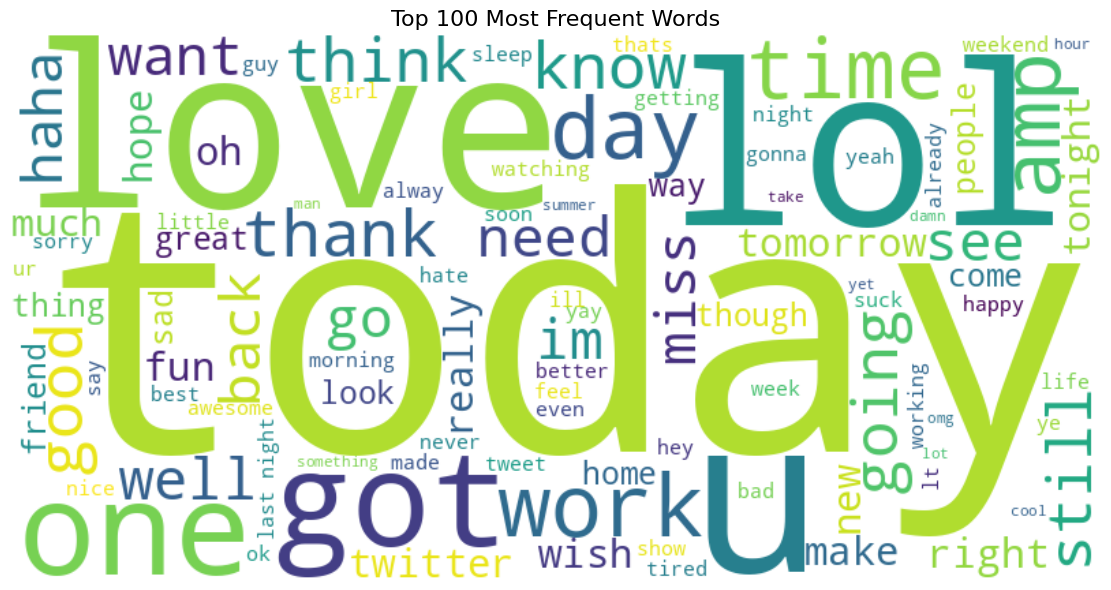

In [ ]:
# ── Visualization 1: Word Cloud ───────────────────────────────────────────────
all_words = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words', fontsize=16)
plt.tight_layout()
plt.show()

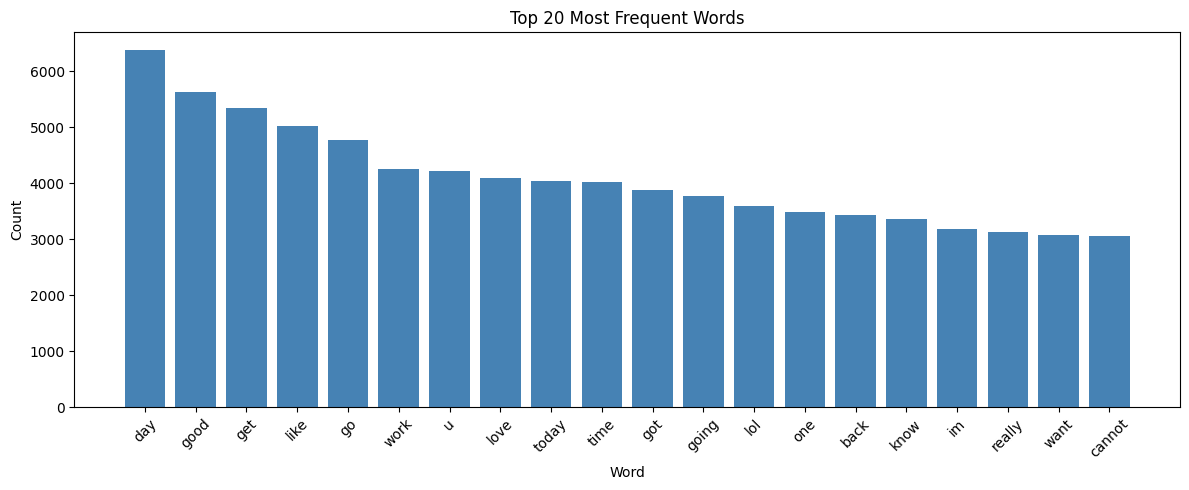

In [ ]:
# ── Visualization 2: Top 20 Most Frequent Words (Bar Chart) ──────────────────
from collections import Counter

word_counts = Counter(all_words.split())
top20 = word_counts.most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 2: Tokenization & Padding

In [ ]:
# ── Split FIRST (before tokenization) ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    data['cleaned_text'],
    data['sentiment'],
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 80000
Test size: 20000


In [ ]:
# ── Tokenization ──────────────────────────────────────────────────────────────
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # Vocabulary built ONLY on training data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print("Sample sequence:", X_train_seq[0][:10])

Sample sequence: [505, 573, 461, 3, 26, 513, 262]


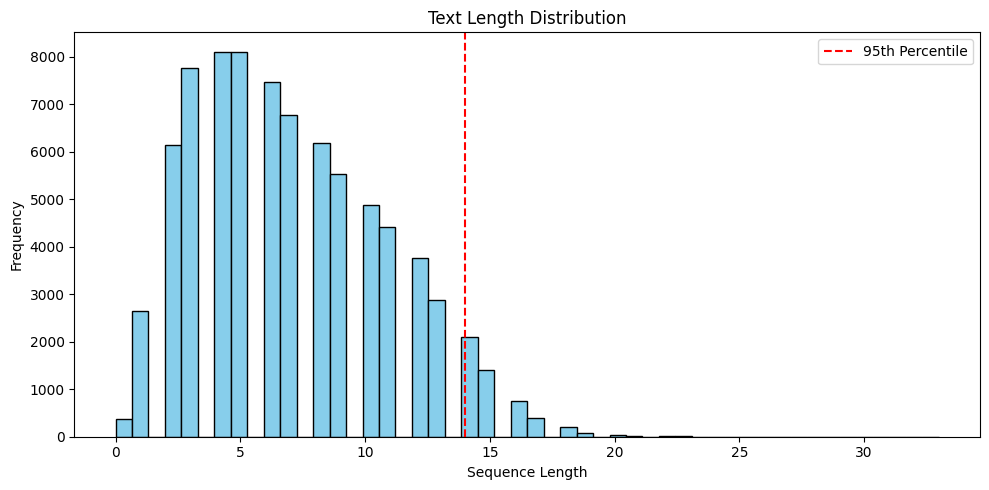

Max length (95th percentile): 14


In [ ]:
# ── Percentile-Based Padding ──────────────────────────────────────────────────
seq_lengths = [len(seq) for seq in X_train_seq]

# Visualize token length distribution
plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', label='95th Percentile')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

MAX_LEN = int(np.percentile(seq_lengths, 95))
print("Max length (95th percentile):", MAX_LEN)

In [ ]:
# ── Apply Padding ─────────────────────────────────────────────────────────────
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(y_train)
y_test  = np.array(y_test)

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape: ", X_test_pad.shape)

X_train_pad shape: (80000, 14)
X_test_pad shape:  (20000, 14)


## Task 3: Model Building

In [ ]:
# ── Model 1: Simple RNN ───────────────────────────────────────────────────────
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # Binary classification
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Model 2: LSTM ─────────────────────────────────────────────────────────────
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # Binary classification
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training & Evaluation

In [ ]:
# ── Train Simple RNN ──────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Training Simple RNN...")
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Training Simple RNN...
Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.7238 - loss: 0.5485 - val_accuracy: 0.7455 - val_loss: 0.5186
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.7929 - loss: 0.4528 - val_accuracy: 0.7419 - val_loss: 0.5404
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.8452 - loss: 0.3625 - val_accuracy: 0.7224 - val_loss: 0.6136
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.8800 - loss: 0.2936 - val_accuracy: 0.7226 - val_loss: 0.6470
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
early_stop2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Training LSTM...")
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

Training LSTM...
Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.7272 - loss: 0.5325 - val_accuracy: 0.7480 - val_loss: 0.5068
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.7828 - loss: 0.4557 - val_accuracy: 0.7520 - val_loss: 0.5047
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.8049 - loss: 0.4128 - val_accuracy: 0.7521 - val_loss: 0.5412
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.8282 - loss: 0.3662 - val_accuracy: 0.7446 - val_loss: 0.6068
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.8495 - loss: 0.3255 - val_accuracy: 0.7376 - val_loss: 0.6271
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
# ── Evaluate Both Models ──────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*50}")
    print(f"  {model_name} - Evaluation")
    print(f"{'='*50}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    return y_pred, cm

rnn_pred, rnn_cm = evaluate_model(rnn_model, X_test_pad, y_test, "Simple RNN")
lstm_pred, lstm_cm = evaluate_model(lstm_model, X_test_pad, y_test, "LSTM")


  Simple RNN - Evaluation
Accuracy: 0.7486

Confusion Matrix:
[[7079 2999]
 [2030 7892]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.70      0.74     10078
    Positive       0.72      0.80      0.76      9922

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000


  LSTM - Evaluation
Accuracy: 0.7559

Confusion Matrix:
[[7700 2378]
 [2504 7418]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.76      0.76     10078
    Positive       0.76      0.75      0.75      9922

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



## Task 5: Visualization

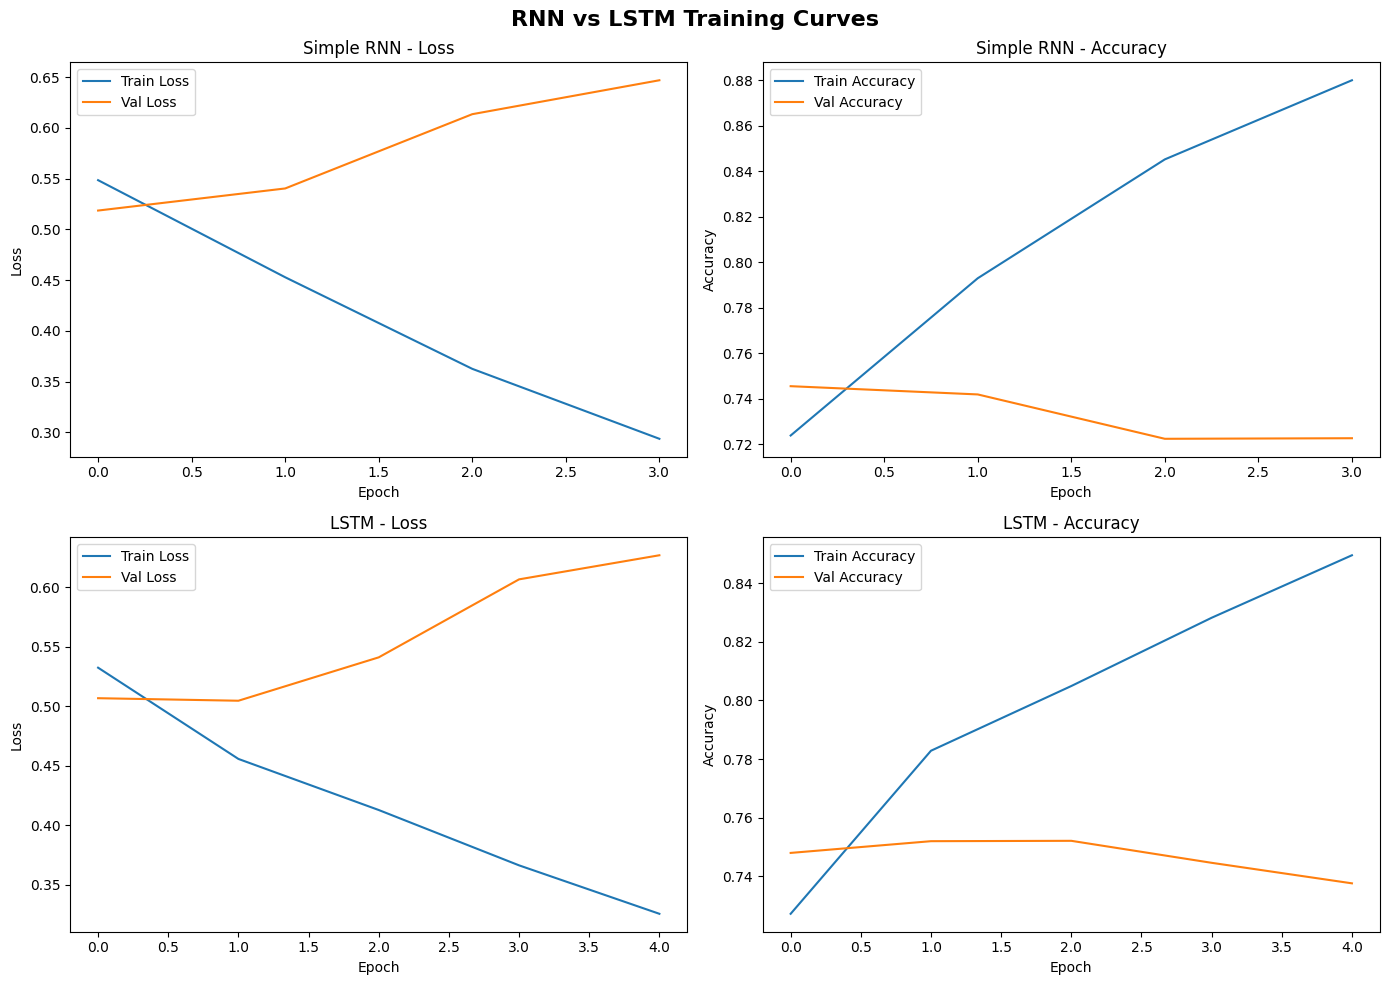

In [ ]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
def plot_history(rnn_hist, lstm_hist):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # RNN Loss
    axes[0, 0].plot(rnn_hist.history['loss'], label='Train Loss')
    axes[0, 0].plot(rnn_hist.history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Simple RNN - Loss')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

    # RNN Accuracy
    axes[0, 1].plot(rnn_hist.history['accuracy'], label='Train Accuracy')
    axes[0, 1].plot(rnn_hist.history['val_accuracy'], label='Val Accuracy')
    axes[0, 1].set_title('Simple RNN - Accuracy')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    # LSTM Loss
    axes[1, 0].plot(lstm_hist.history['loss'], label='Train Loss')
    axes[1, 0].plot(lstm_hist.history['val_loss'], label='Val Loss')
    axes[1, 0].set_title('LSTM - Loss')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()

    # LSTM Accuracy
    axes[1, 1].plot(lstm_hist.history['accuracy'], label='Train Accuracy')
    axes[1, 1].plot(lstm_hist.history['val_accuracy'], label='Val Accuracy')
    axes[1, 1].set_title('LSTM - Accuracy')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()

    plt.suptitle('RNN vs LSTM Training Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(rnn_history, lstm_history)

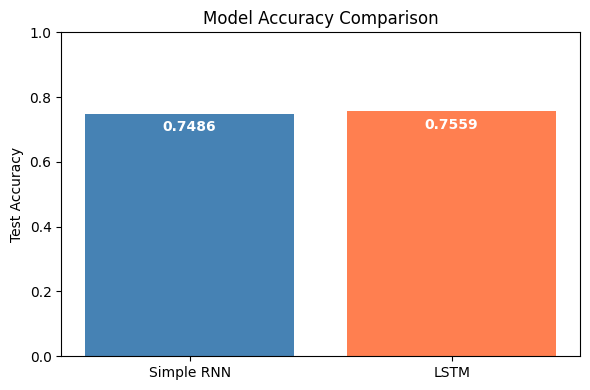

Simple RNN Accuracy : 0.7486
LSTM Accuracy       : 0.7559


In [ ]:
# ── Compare Final Accuracy: RNN vs LSTM ───────────────────────────────────────
rnn_acc  = accuracy_score(y_test, rnn_pred)
lstm_acc = accuracy_score(y_test, lstm_pred)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Simple RNN', 'LSTM'], [rnn_acc, lstm_acc], color=['steelblue', 'coral'])
for bar, acc in zip(bars, [rnn_acc, lstm_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
             f'{acc:.4f}', ha='center', va='top', color='white', fontweight='bold')
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.tight_layout()
plt.show()

print(f"Simple RNN Accuracy : {rnn_acc:.4f}")
print(f"LSTM Accuracy       : {lstm_acc:.4f}")

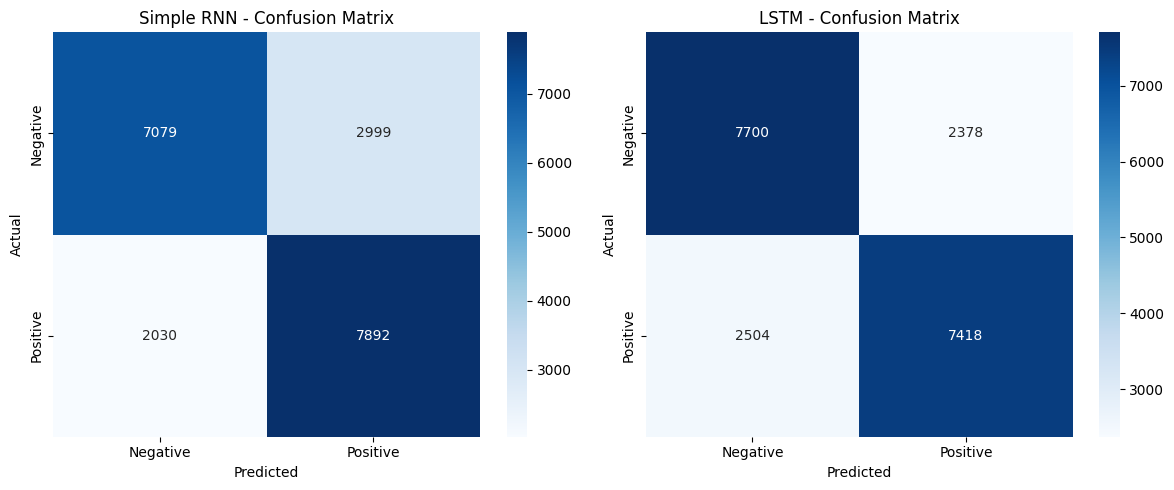

In [ ]:
# ── Confusion Matrix Heatmaps ─────────────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(axes, [rnn_cm, lstm_cm], ['Simple RNN', 'LSTM']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Task 6 (Optional): Simple Gradio GUI for Real-Time Prediction

In [ ]:
!pip install gradio -q

import gradio as gr

def predict_sentiment(tweet):
    cleaned = preprocess_text(tweet)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    rnn_prob  = float(rnn_model.predict(padded, verbose=0)[0][0])
    lstm_prob = float(lstm_model.predict(padded, verbose=0)[0][0])

    def label(prob):
        return f"{'Positive 😊' if prob > 0.5 else 'Negative 😞'} ({prob:.2%})"

    return label(rnn_prob), label(lstm_prob)

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(label="Enter a Tweet", placeholder="Type something..."),
    outputs=[
        gr.Textbox(label="Simple RNN Prediction"),
        gr.Textbox(label="LSTM Prediction")
    ],
    title="Twitter Sentiment Analyzer",
    description="Compare Simple RNN vs LSTM sentiment predictions in real time."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://040cad0ae91ba102a0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
